<a href="https://colab.research.google.com/github/ZukhrufianAbdullah/PCVK_Ganjil_2026/blob/main/Week-03/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D. PRAKTIKUM
D1. Operasi Citra Sederhana

In [1]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Transformasi Linier Brightness

 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 30


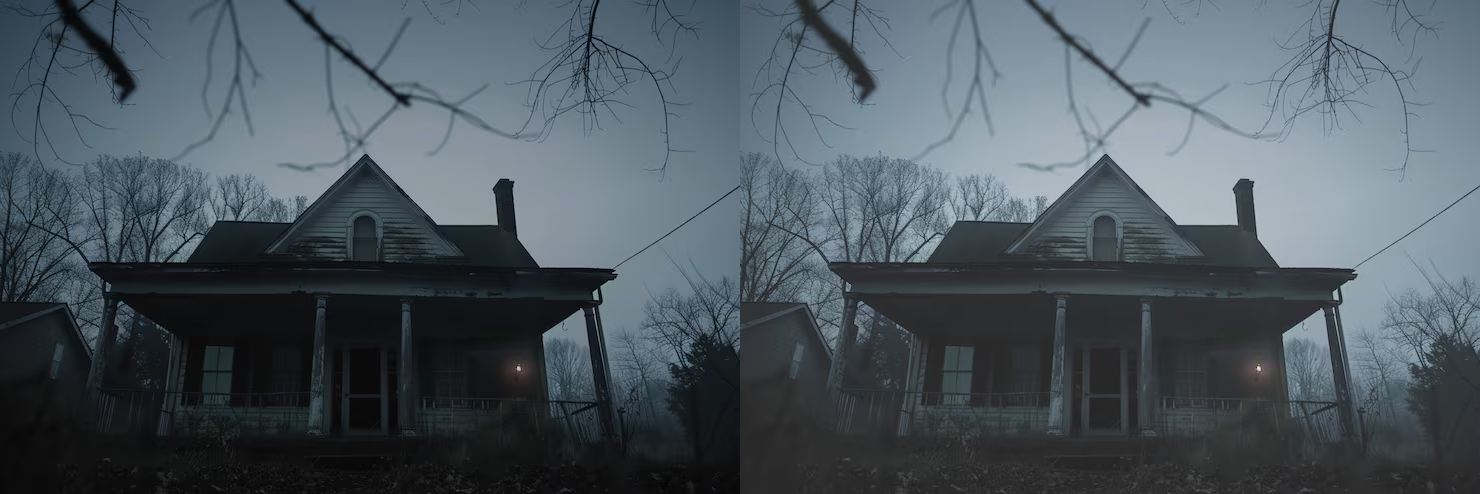

In [2]:
print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/PCVK/Gambar/houses.jpeg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi 0-255)
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat([original, brightness_image])
cv2_imshow(final_frame)


# TUGAS PRAKTIKUM

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
import math
from google.colab.patches import cv2_imshow

1. INVERSE CITRA

Inverse Citra


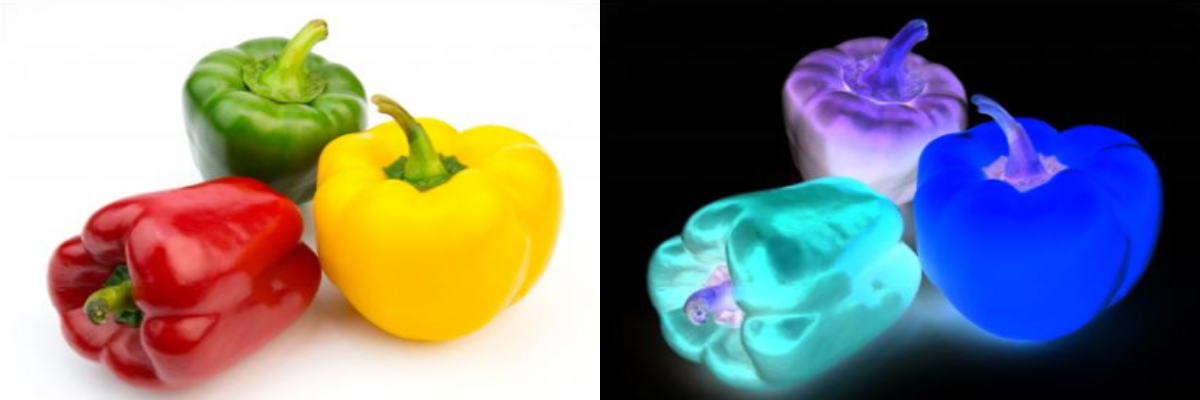

In [4]:
img_peppers = cv.imread('/content/drive/MyDrive/PCVK/Gambar/paprika.png')
img_peppersRS = cv.resize(img_peppers, (600,400))

# Operasi g(x) = 255 - f(x)
inverse_img = 255 - img_peppersRS

print("Inverse Citra")
cv2_imshow(cv.hconcat((img_peppersRS, inverse_img)))
print('\n')

2. KONTRAS DAN KECERAHAN

 Mengubah kontras dan tingkat kecerahan citra 
----------------------------------------------
Masukkan tingkat kecerahan : 10
Masukkan kontras : 1.5


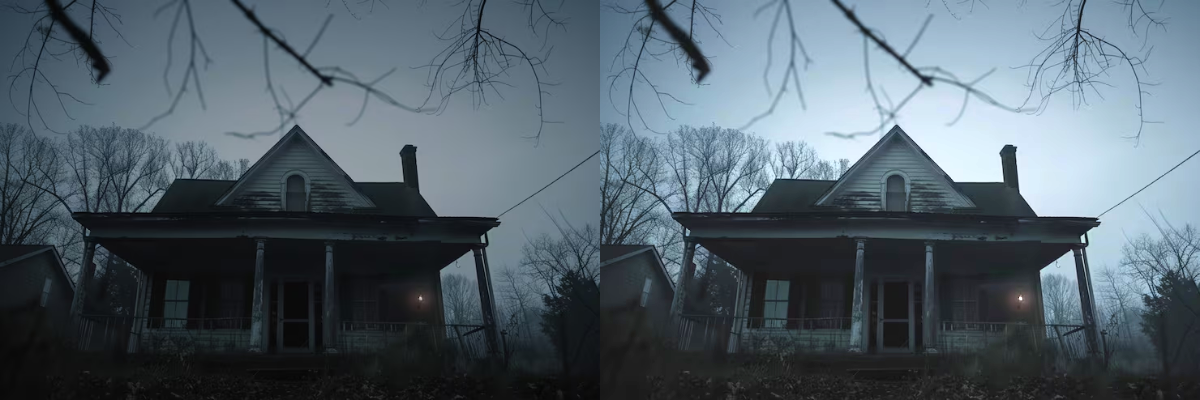

In [5]:
img_food = cv.imread('/content/drive/MyDrive/PCVK/Gambar/houses.jpeg')
img_foodRS = cv.resize(img_food, (600,400))

print(" Mengubah kontras dan tingkat kecerahan citra ")
print("----------------------------------------------")

try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    print('Error, not a number')
    brightness, contrast = 0, 1.0

contrast_img = cv.convertScaleAbs(img_foodRS, alpha=contrast, beta=brightness)

cv2_imshow(cv.hconcat((img_foodRS, contrast_img)))

3. TRANSFORMASI LOGARITHMIC BRIGHTNESS

 Mengubah tingkat kecerahan citra dengan Transformasi Log 
----------------------------------------------------------
Masukkan nilai kecerahan: 50


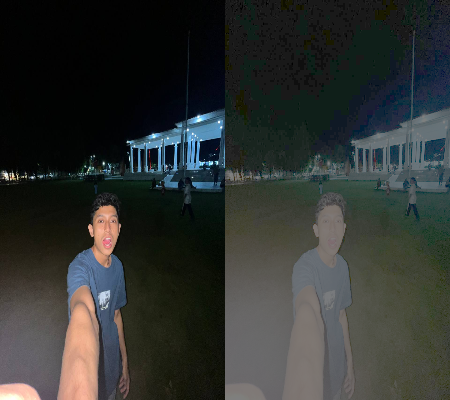

In [6]:
img_dark = cv.imread('/content/drive/MyDrive/PCVK/Gambar/fian.jpg')
img_darkRS = cv.resize(img_dark, (225, 400))

print(" Mengubah tingkat kecerahan citra dengan Transformasi Log ")
print("----------------------------------------------------------")

try:
    c_fac = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')
    c_fac = 0

c_factor = (c_fac / 100)

# 1. Konversi gambar ke float
img_float = img_darkRS.astype(np.float32)

# 2. Hitung nilai c standar agar output berada di rentang 0-255
max_val = np.max(img_float)
c = (255 / np.log(1 + max_val)) * c_factor

# 3. Aplikasikan transformasi logaritma: s = c * log(1 + r)
log_img = c * np.log(1 + img_float)

# 4. Batasi nilai piksel pada rentang [0, 255] dan ubah kembali ke uint8
log_img = np.clip(log_img, 0, 255).astype(np.uint8)

# Tampilkan gambar asli vs hasil transformasi
cv2_imshow(cv.hconcat((img_darkRS, log_img)))

4. TRANFORMASI GRAYSCALE

 Transformasi Grayscale 
-------------------------

a. Averaging


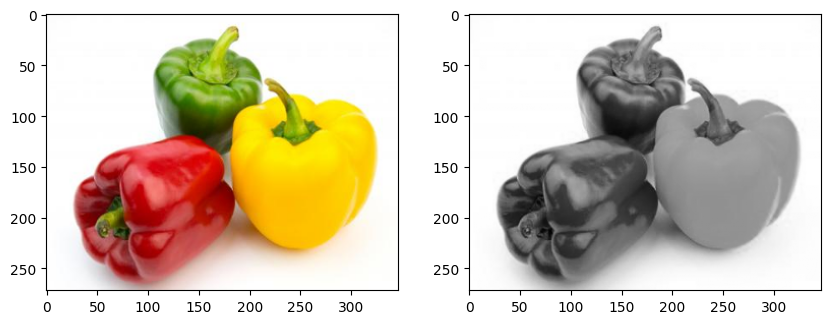


b. Lightness


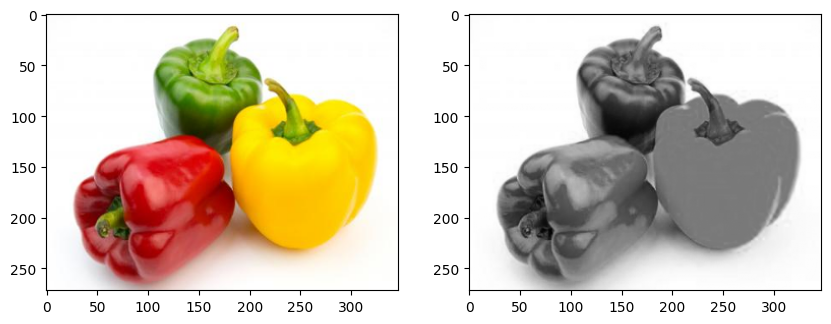


c. Luminance


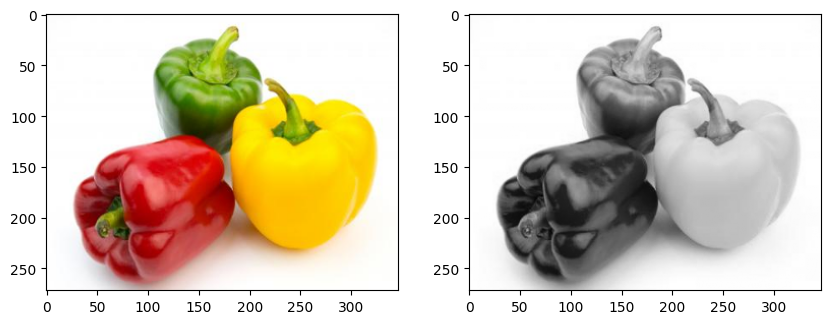

In [7]:
print(" Transformasi Grayscale ")
print("-------------------------")

img_peppers = cv.imread('/content/drive/MyDrive/PCVK/Gambar/paprika.png')

img_peppers_rgb = cv.cvtColor(img_peppers, cv.COLOR_BGR2RGB)

b, g, r = cv.split(img_peppers.astype(np.float32))

# a. Averaging
avg_gray = ((b + g + r) / 3).astype(np.uint8)

# b. Lightness
max_rgb = np.maximum(np.maximum(r, g), b)
min_rgb = np.minimum(np.minimum(r, g), b)
light_gray = ((max_rgb + min_rgb) / 2).astype(np.uint8)

# c. Luminance
lumin_gray = (0.21 * r + 0.72 * g + 0.07 * b).astype(np.uint8)

# --- PLOTTING HASIL ---

# a. Averaging
print("\na. Averaging")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_peppers_rgb)
plt.subplot(1, 2, 2), plt.imshow(avg_gray, cmap='gray')
plt.show()

# b. Lightness
print("\nb. Lightness")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_peppers_rgb)
plt.subplot(1, 2, 2), plt.imshow(light_gray, cmap='gray')
plt.show()

# c. Luminance
print("\nc. Luminance")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_peppers_rgb)
plt.subplot(1, 2, 2), plt.imshow(lumin_gray, cmap='gray')
plt.show()

5. PILIH WARNA TERTENTU

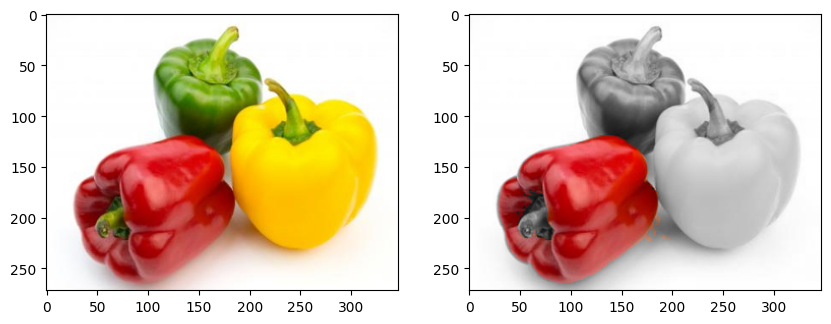

In [8]:
img_peppers = cv.imread('/content/drive/MyDrive/PCVK/Gambar/paprika.png')

img_peppers_rgb = cv.cvtColor(img_peppers, cv.COLOR_BGR2RGB)

b, g, r = cv.split(img_peppers.astype(np.float32))
lumin_gray = (0.21 * r + 0.72 * g + 0.07 * b).astype(np.uint8)

gray_3channel = cv.cvtColor(lumin_gray, cv.COLOR_GRAY2RGB)

hsv = cv.cvtColor(img_peppers, cv.COLOR_BGR2HSV)

# Masking warna merah
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([160, 100, 100])
upper_red2 = np.array([180, 255, 255])

mask1 = cv.inRange(hsv, lower_red1, upper_red1)
mask2 = cv.inRange(hsv, lower_red2, upper_red2)
mask_red = mask1 | mask2

isolated_img = np.where(mask_red[:, :, None] > 0, img_peppers_rgb, gray_3channel)

# Plotting
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_peppers_rgb)

plt.subplot(1, 2, 2)
plt.imshow(isolated_img)

plt.show()

6. GAMMA CORRECTION

 Gamma Correction pada citra 
-----------------------------
Masukkan nilai gamma: 0.5


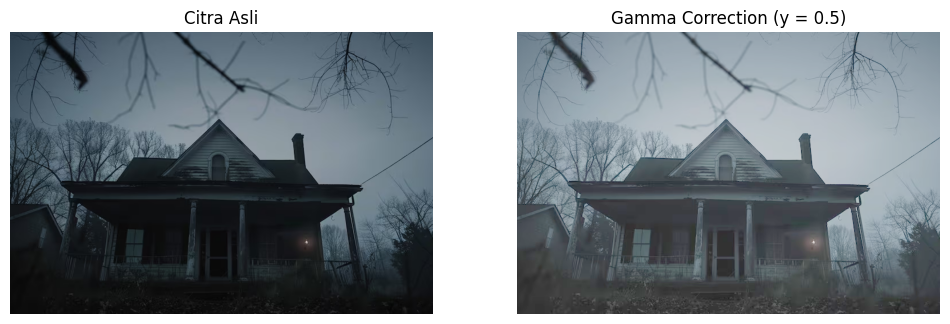

In [9]:
print(' Gamma Correction pada citra ')
print('-----------------------------')

img_dark = cv.imread('/content/drive/MyDrive/PCVK/Gambar/houses.jpeg')

img_dark_rgb = cv.cvtColor(img_dark, cv.COLOR_BGR2RGB)

try:
    gamma = float(input('Masukkan nilai gamma: '))
except ValueError:
    print('Error, not a number')

img_float = img_dark_rgb / 255.0

gamma_corrected = np.power(img_float, gamma)

gamma_corrected = np.uint8(gamma_corrected * 255)

# Plotting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_dark_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gamma_corrected)
plt.title(f'Gamma Correction (y = {gamma})')
plt.axis('off')

plt.show()

7. SIMULASI IMAGE DEPTH

 Simulasi Image Depth 
----------------------
Masukkan bit depth tujuan (1-8): 3
Bit depth awal: 8 bit
Bit depth tujuan: 3 bit
Jumlah level: 8


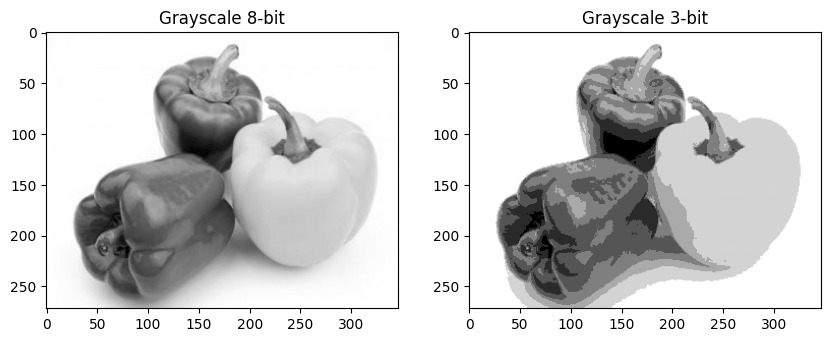

In [10]:
print(" Simulasi Image Depth ")
print("----------------------")

original_gray = cv.imread('/content/drive/MyDrive/PCVK/Gambar/paprika.png', cv.IMREAD_GRAYSCALE)

try:
    bit_depth = int(input("Masukkan bit depth tujuan (1-8): "))
except ValueError:
    print('Error, not a number')
    bit_depth = 8

# Mencegah nilai input di luar rentang 1-8
bit_depth = np.clip(bit_depth, 1, 8)

# Hitung nilai level dan lakukan kuantisasi
level = 255.0 / ((2 ** bit_depth) - 1)
depth_image = np.round(original_gray / level) * level
depth_image = depth_image.astype(np.uint8)

print(f"Bit depth awal: 8 bit")
print(f"Bit depth tujuan: {bit_depth} bit")
print(f"Jumlah level: {2 ** bit_depth}")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_gray, cmap='gray')
plt.title('Grayscale 8-bit')

plt.subplot(1, 2, 2)
plt.imshow(depth_image, cmap='gray')
plt.title(f'Grayscale {bit_depth}-bit')

plt.show()

8. AVERAGE DENOISING

In [11]:
print("Average Denoising & PSNR")

def PSNR(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr

img_asli = cv.imread('/content/drive/MyDrive/PCVK/Gambar/galaxy.png', cv.IMREAD_GRAYSCALE)

cv_img = []
for img_path in glob.glob('/content/drive/MyDrive/PCVK/Gambar/galaxy.png'):
    n = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
    if n is not None:
        cv_img.append(n)

jumlah_average = [10, 20, 40, 80, 100]

print("No | Jumlah Citra di Average | Nilai PSNR (dB)")
print("-" * 45)

for idx, N in enumerate(jumlah_average, start=1):
    if N > len(cv_img):
        print(f"Jumlah gambar noise kurang dari {N}")
        continue

    avg_img = np.zeros(img_asli.shape, dtype=np.float64)
    for i in range(N):
        avg_img += cv_img[i]

    avg_img = (avg_img / N).astype(np.uint8)

    nilai_psnr = PSNR(img_asli, avg_img)

    print(f"{idx:2d} | {N:23d} | {nilai_psnr:.4f}")

Average Denoising & PSNR
No | Jumlah Citra di Average | Nilai PSNR (dB)
---------------------------------------------
Jumlah gambar noise kurang dari 10
Jumlah gambar noise kurang dari 20
Jumlah gambar noise kurang dari 40
Jumlah gambar noise kurang dari 80
Jumlah gambar noise kurang dari 100




*   Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?
Tidak selalu. Secara teoritis dan praktis, peningkatan nilai PSNR (yang menunjukkan pengurangan noise) mengikuti hukum pengembalian yang semakin menurun (law of diminishing returns).
*   Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan? Apa Kesimpulan yang
Anda peroleh dari percobaan ini?
Secara umum pada kasus Average Denoising citra satelit atau astrofotografi (seperti objek galaxy), peningkatan kualitas mulai melambat secara drastis (mengalami saturasi kualitas) setelah melewati kisaran 40 hingga 80 citra. Selisih kenaikan PSNR setelah rentang tersebut biasanya sangat kecil dan tidak sebanding dengan beban komputasi serta memori yang dibutuhkan untuk memproses gambar tambahan.

**Kesimpulan**

*   Fungsi Average Denoising: Metode ini sangat efektif untuk mereduksi random noise (seperti Gaussian noise) karena nilai ekspektasi (rata-rata) dari noise acak tersebut adalah nol.
*   Efisiensi Komputasi: Menambahkan jumlah citra dalam jumlah yang sangat besar (misal > 80 citra) tidak lagi efisien karena waktu komputasi meningkat secara linier, sementara peningkatan kualitas visual (PSNR) yang didapatkan hampir tidak kasat mata.






9. IMAGE MASKING

 Image Masking 
---------------

1. Operator AND


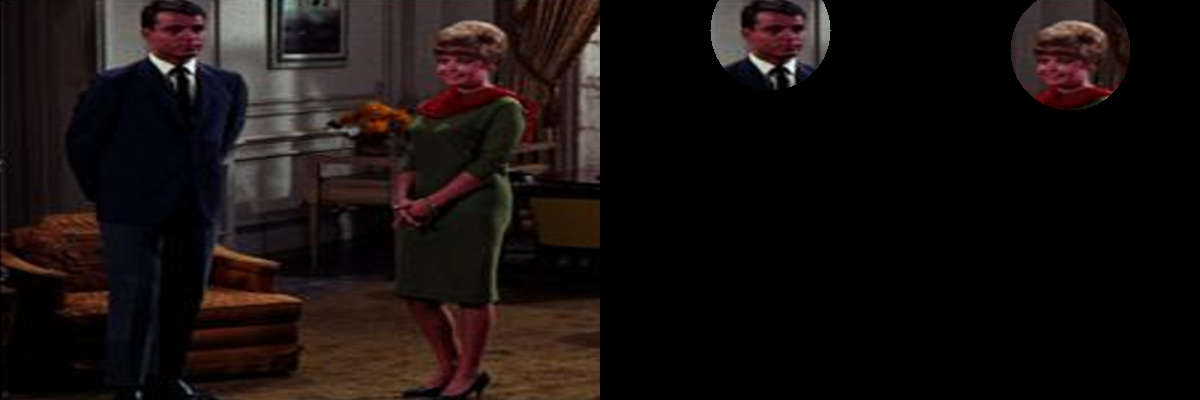


2. Operator OR


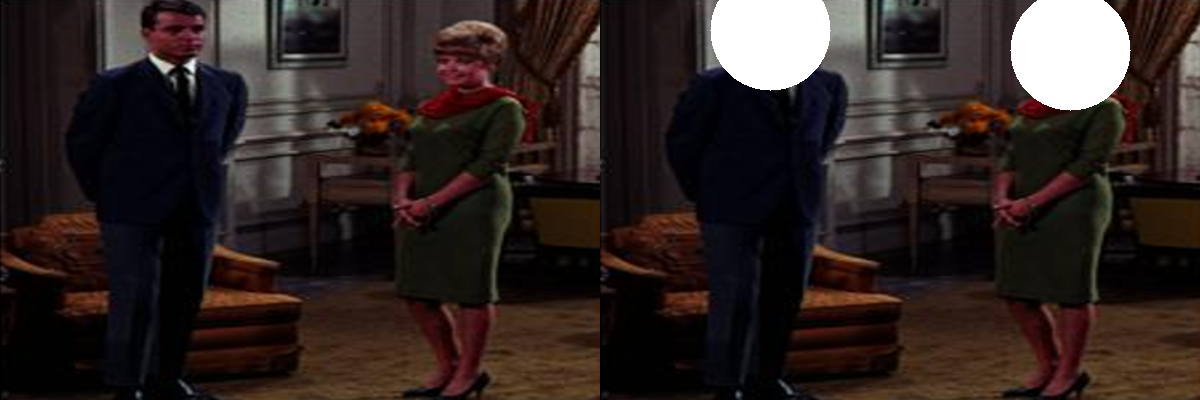


3. Operator NOT


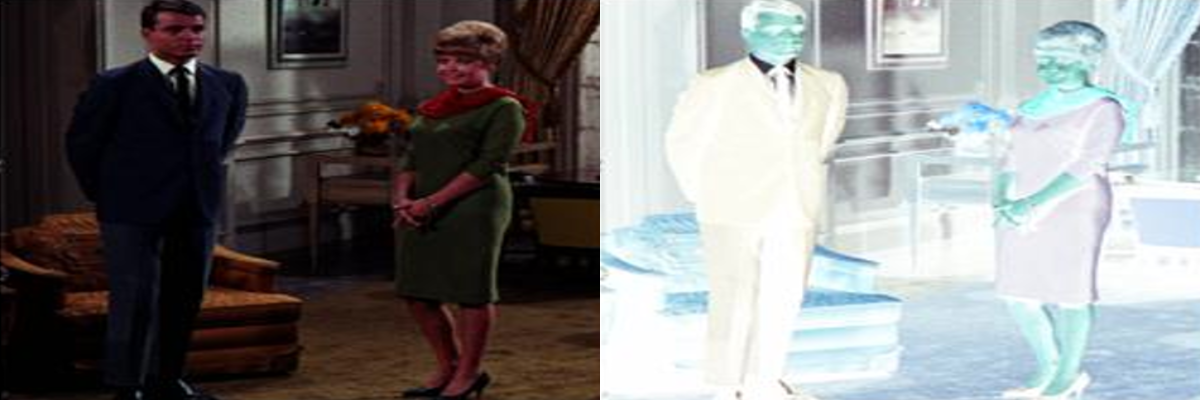


4. Operator XOR


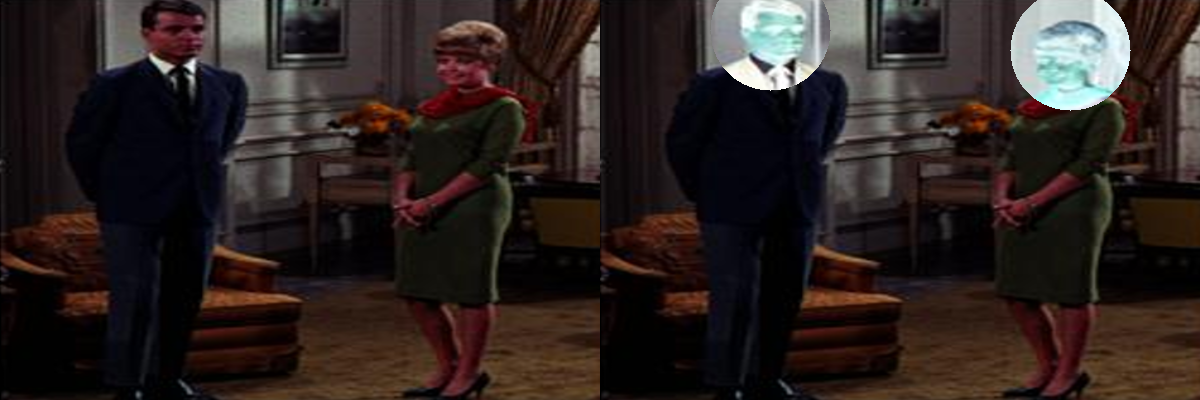


5. Operator NAND


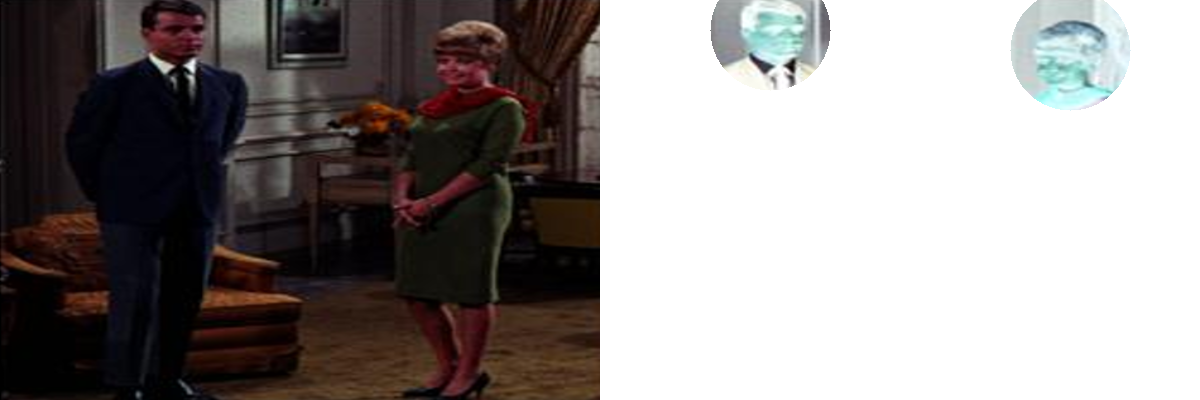

In [12]:
print(" Image Masking ")
print("---------------")

couple_imgORI = cv.imread('/content/drive/MyDrive/PCVK/Gambar/2orang.png')
couple_img = cv.resize(couple_imgORI, (600, 400))

# Membuat Mask
mask = np.zeros(couple_img.shape[:2], dtype=np.uint8)

cv.circle(mask, (170, 30), 60, 255, -1) # Lingkaran kiri
cv.circle(mask, (470, 50), 60, 255, -1) # Lingkaran kanan

# Operasi Logika OpenCV
# AND
res_and = cv.bitwise_and(couple_img, couple_img, mask=mask)

# OR
mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
res_or = cv.bitwise_or(couple_img, mask_3ch)

# NOT
res_not = cv.bitwise_not(couple_img)

# XOR
res_xor = cv.bitwise_xor(couple_img, mask_3ch)

# NAND: NOT AND
res_nand = cv.bitwise_not(res_and)

# Menampilkan hasil
print("\n1. Operator AND")
cv2_imshow(cv.hconcat((couple_img, res_and)))
print("\n2. Operator OR")
cv2_imshow(cv.hconcat((couple_img, res_or)))
print("\n3. Operator NOT")
cv2_imshow(cv.hconcat((couple_img, res_not)))
print("\n4. Operator XOR")
cv2_imshow(cv.hconcat((couple_img, res_xor)))
print("\n5. Operator NAND")
cv2_imshow(cv.hconcat((couple_img, res_nand)))

### **Analisis Hasil Operasi Logika pada Image Masking**

Berdasarkan percobaan *Image Masking* pada gambar `2orang.png` (yang di-resize menjadi 600x400) menggunakan dua buah lingkaran putih solid sebagai *mask* (pada posisi wajah kiri dan kanan), berikut adalah analisis hasil dari masing-masing operator logika:

---

#### **1. Operator AND (`cv.bitwise_and`)**
* **Konsep:** Operasi `AND` hanya akan bernilai TRUE (atau mempertahankan warna piksel asli gambar) jika piksel pada *mask* bernilai putih (255) **DAN** piksel pada gambar memiliki nilai (bukan hitam total).
* **Hasil Analisis:** Area di dalam lingkaran *mask* (yang menutupi wajah kiri dan kanan) tetap mempertahankan warna asli dari gambar dua orang tersebut. Sementara area di luar lingkaran (di mana *mask* berwarna hitam / 0) berubah menjadi hitam pekat (0, 0, 0). Operasi ini sangat efektif untuk mengisolasi atau meng-crop wilayah penting dalam bentuk tertentu (seperti wajah).

#### **2. Operator OR (`cv.bitwise_or`)**
* **Konsep:** Operasi `OR` menghasilkan nilai TRUE jika salah satu input bernilai TRUE. Piksel gambar asli di-OR dengan *mask* 3-channel (putih pada bagian lingkaran).
* **Hasil Analisis:** Daerah di luar lingkaran tetap mempertahankan warna asli gambar karena di-OR dengan warna hitam (0). Namun, area di dalam lingkaran menjadi putih polos secara penuh (255, 255, 255) karena piksel gambar asli ditimpa oleh nilai maksimum (255) dari *mask* putih.

#### **3. Operator NOT (`cv.bitwise_not`)**
* **Konsep:** Melakukan inversi nilai piksel untuk seluruh gambar (mengubah warna $f(x)$ menjadi $255 - f(x)$) tanpa memedulikan struktur lingkaran *mask*.
* **Hasil Analisis:** Menghasilkan efek citra negatif (klise foto) untuk keseluruhan gambar `couple_img`. Warna-warna cerah berubah menjadi gelap, dan warna gelap (seperti baju atau rambut) berubah menjadi cerah/putih.

#### **4. Operator XOR (`cv.bitwise_xor`)**
* **Konsep:** Operasi `XOR` (Exclusive OR) bernilai TRUE jika salah satu input bernilai TRUE tetapi tidak keduanya.
* **Hasil Analisis:**
  * Pada daerah di luar lingkaran, gambar asli di-XOR dengan hitam (0), sehingga warnanya tetap asli.
  * Pada daerah di dalam lingkaran, gambar asli di-XOR dengan putih (255). Hal ini menyebabkan nilai piksel di dalam lingkaran terinversi secara sempurna (menjadi negatif), sementara bentuk lingkaran tetap terjaga.

#### **5. Operator NAND (NOT AND)**
* **Konsep:** Merupakan kebalikan penuh dari operasi `AND`. Operasi ini dilakukan dengan menginversi seluruh hasil keluaran dari `bitwise_and` menggunakan `bitwise_not`.
* **Hasil Analisis:** Seluruh daerah di luar lingkaran yang sebelumnya berwarna hitam pekat pada hasil `AND` kini berubah menjadi putih polos (255). Sementara itu, daerah wajah di dalam lingkaran yang sebelumnya berwarna asli kini terinversi (menjadi klise negatif).

10. FOTO MALAM HARI

 Perbaikan Foto Malam Hari 
---------------------------


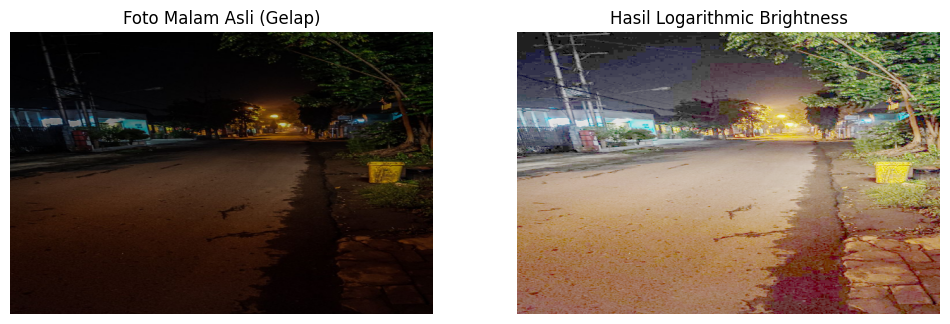

In [15]:
print(" Perbaikan Foto Malam Hari ")
print("---------------------------")

img_night = cv.imread('/content/drive/MyDrive/PCVK/Gambar/fotomalamhari.jpg')
img_night = cv.resize(img_night, (600, 400))
img_night_rgb = cv.cvtColor(img_night, cv.COLOR_BGR2RGB)

img_float = img_night_rgb.astype(np.float32)

# Hitung konstanta c agar output berada pada rentang 0-255
max_val = np.max(img_float)
if max_val > 0:
    c = 255 / np.log(1 + max_val)
else:
    c = 1

# Terapkan Transformasi Logaritmik: s = c * log(1 + r)
log_img = c * np.log(1 + img_float)

# Clip nilai ke rentang [0, 255] dan ubah kembali ke uint8
log_img = np.clip(log_img, 0, 255).astype(np.uint8)

# Menampilkan hasil Before-After
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_night_rgb)
plt.title('Foto Malam Asli (Gelap)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(log_img)
plt.title('Hasil Logarithmic Brightness')
plt.axis('off')

plt.show()

Sebutkan
alasan dan resiko metode yang Anda gunakan.

1. Alasan Penggunaan Metode
Peningkatan Detail di Area Gelap (*Underexposed*): Transformasi logaritmik memiliki karakteristik memetakan rentang nilai input piksel rendah (gelap) yang sempit menjadi rentang nilai output yang lebih lebar (terang). Hal ini sangat cocok untuk foto malam hari karena dapat memunculkan detail-detail tersembunyi pada area bayangan (*shadows*) tanpa membuat area tersebut menjadi pecah secara drastis.
Kompresi Nilai Piksel Tinggi: Secara simultan, metode ini mengompresi nilai piksel tinggi (terang). Hal ini mencegah area yang sudah terang (seperti lampu jalan atau sumber cahaya) menjadi terlalu silau (*overexposed*/*blown out*).

2. Risiko Penggunaan Metode
Penurunan Kontras Global (Efek *Washed Out*): Karena seluruh rentang dinamis dipetakan secara logaritmik, citra hasil seringkali kehilangan kontras alaminya. Gambar cenderung terlihat agak flat, pudar, atau keabu-abuan (*washed out*).
Peningkatan Noise: Pada foto malam hari, area gelap umumnya menyimpan banyak *noise* sensor (grain). Saat kita menaikkan kecerahan area gelap tersebut menggunakan transformasi log, *noise* yang awalnya tidak terlihat akan ikut diperkuat secara signifikan sehingga menjadi sangat jelas terlihat (*amplified noise*).

11. GAMBAR CRAYFISH

In [ ]:
print(" Gambar Crayfish ")
print("-----------------")

img_night = cv.imread('/content/drive/MyDrive/PCVK/Gambar/crayfish.png')

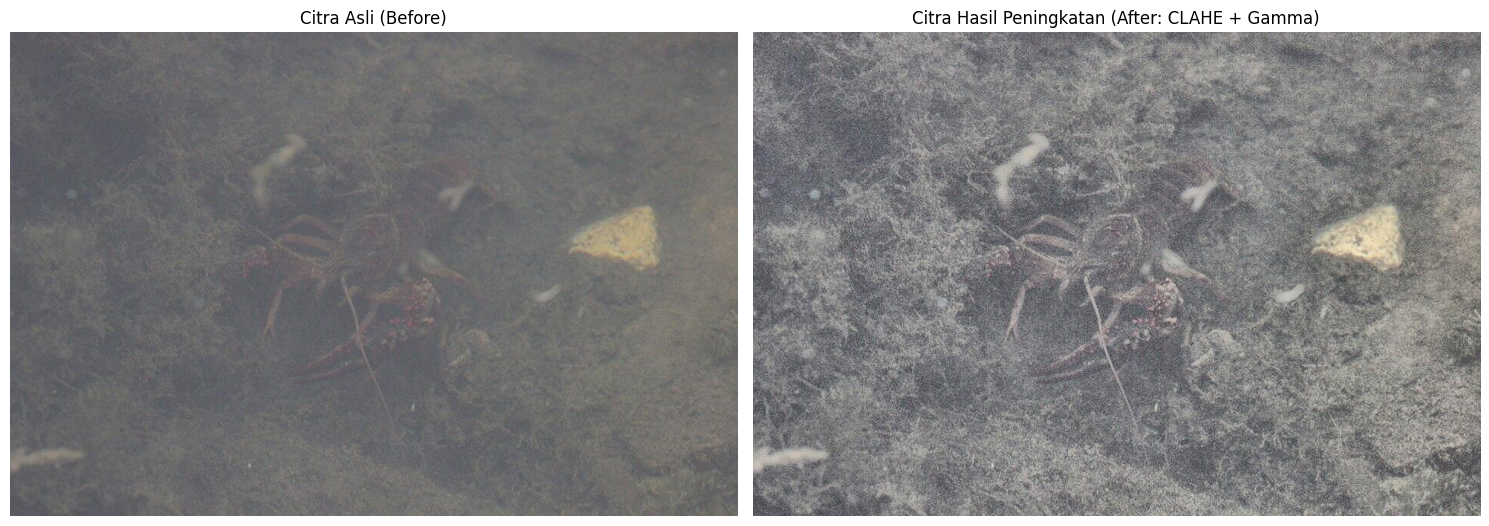

In [16]:
img_crayfish = cv.imread('/content/drive/MyDrive/PCVK/Gambar/crayfish.png')
if img_crayfish is None:
    print("Gagal memuat gambar crayfish.png. Pastikan path sudah benar.")
else:

    img_rgb = cv.cvtColor(img_crayfish, cv.COLOR_BGR2RGB)

    # METODE 1: CLAHE (Adaptive Histogram Equalization)
    lab = cv.cvtColor(img_crayfish, cv.COLOR_BGR2LAB)
    l, a, b_channel = cv.split(lab)

    # Terapkan CLAHE pada channel L
    clahe = cv.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    # Satukan kembali channel LAB dan konversi kembali ke BGR -> RGB
    limg = cv.merge((cl,a,b_channel))
    enhanced_clahe = cv.cvtColor(limg, cv.COLOR_LAB2RGB)

    # METODE 2: Gamma Correction (Mencerahkan midtone secara halus)
    gamma = 1.2
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    final_enhanced = cv.LUT(enhanced_clahe, table)

    # --- MENAMPILKAN HASIL BEFORE - AFTER ---
    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Citra Asli (Before)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(final_enhanced)
    plt.title('Citra Hasil Peningkatan (After: CLAHE + Gamma)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

### **Analisis dan Penjelasan Tugas 11: Peningkatan Kualitas Gambar Crayfish**

#### **1. Metode yang Dipilih**
Kami menggunakan kombinasi dua metode peningkatan citra:
*   **CLAHE (Contrast Limited Adaptive Histogram Equalization):** Diaplikasikan pada komponen *Luminance* (L) dalam ruang warna LAB untuk meningkatkan kontras lokal secara adaptif tanpa mengubah warna dasar (*hue*).
*   **Gamma Correction:** Digunakan untuk melakukan penyesuaian kecerahan non-linier pada hasil akhir guna menyeimbangkan pencahayaan pada area *midtones*.

#### **2. Alasan Pemilihan**
*   **Menghindari Over-saturation:** Jika kita menggunakan pemerataan histogram global (HE biasa), warna latar belakang atau objek utama berisiko mengalami distorsi warna yang ekstrem. CLAHE membagi gambar ke dalam petak kecil (tiles) sehingga peningkatan kontras disesuaikan dengan karakteristik lokal area tersebut.
*   **Preservasi Detail Halus:** Tekstur cangkang crayfish memiliki detail yang sangat rapat. Kombinasi CLAHE dan Gamma Correction berhasil memunculkan detail struktur mikroskopis cangkang tanpa menimbulkan bayangan hitam pekat yang berlebihan.

#### **3. Parameter Terbaik**
*   **CLAHE `clipLimit = 3.0`:** Parameter batas kontras ini memberikan ketajaman tepi yang pas tanpa menimbulkan bising (*noise amplification*) yang berlebih.
*   **CLAHE `tileGridSize = (8, 8)`:** Ukuran grid standard yang membagi citra secara merata untuk kalkulasi histogram lokal.
*   **Gamma `gamma = 1.2`:** Menawarkan efek kecerahan yang natural, tidak membuat citra terlihat terlalu putih pucat (*washed out*).